<a href="https://colab.research.google.com/github/Piyush-Sharma-1/Diffusion_from_Scratch/blob/main/Copy_of_2dVAE_SOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# config

DATASET_NAME = 'blobs'  # moons, circles, blobs
N_SAMPLES = 3000
NOISE = 0.07
BATCH_SIZE = 256
dataset = 'blobs'

LATENT_DIM = 4
HIDDEN_DIM = 128

EPOCHS = 600
LR = 1e-3
BETA = 0.1
ANNEAL_EPOCHS = 300

INTERP_STEPS = 20


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles, make_blobs

torch.manual_seed(42)
np.random.seed(42)


In [ ]:
def get_data(dataset, batch_size=256, n=3000, noise=0.05):
    if dataset == 'moons':
        X, y = make_moons(n_samples=n, noise=noise)
    elif dataset == 'circles':
        X, y = make_circles(n_samples=n, noise=noise, factor=0.5)
    elif dataset == 'blobs':
        X, y = make_blobs(n_samples=n, centers=3, cluster_std=1.0)
        X = (X - X.mean(0)) / X.std(0)
    else:
        raise ValueError("dataset must be moons, circles or blobs")

    X = torch.FloatTensor(X)
    y = torch.LongTensor(y)
    dataset_obj = TensorDataset(X, y)
    return DataLoader(dataset_obj, batch_size=batch_size, shuffle=True)

train_loader = get_data(DATASET_NAME, batch_size=BATCH_SIZE, n=N_SAMPLES, noise=NOISE)

all_data = torch.cat([batch[0] for batch in train_loader], dim=0)
all_labels = torch.cat([batch[1] for batch in train_loader], dim=0)

In [ ]:
class DeepVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=4, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')

    # kl divergence, averaged over batch and dims
    kl_element = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean(kl_element)

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


In [ ]:
def train_vae(model, train_loader, epochs=200, lr=1e-3, target_beta=1.0, anneal_epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0

        # linear beta annealing
        if epoch < anneal_epochs:
            beta = target_beta * (epoch / anneal_epochs)
        else:
            beta = target_beta

        for batch in train_loader:
            x = batch[0]
            recon_x, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        history['loss'].append(total_loss)
        history['recon'].append(total_recon)
        history['kl'].append(total_kl)

        if epoch % 40 == 0:
            print(f"epoch {epoch} beta={beta:.2f} loss={total_loss:.1f} recon={total_recon:.1f} kl={total_kl:.1f}")

    return history


epoch 0 beta=0.00 loss=10.1 recon=10.1 kl=1.1
epoch 40 beta=0.01 loss=0.2 recon=0.0 kl=15.3
epoch 80 beta=0.03 loss=0.4 recon=0.1 kl=11.8
epoch 120 beta=0.04 loss=0.5 recon=0.1 kl=9.5
epoch 160 beta=0.05 loss=0.6 recon=0.2 kl=7.9
epoch 200 beta=0.07 loss=0.7 recon=0.2 kl=7.4
epoch 240 beta=0.08 loss=0.8 recon=0.2 kl=7.2
epoch 280 beta=0.09 loss=0.9 recon=0.2 kl=7.1
epoch 320 beta=0.10 loss=0.9 recon=0.3 kl=6.5
epoch 360 beta=0.10 loss=0.9 recon=0.2 kl=6.5
epoch 400 beta=0.10 loss=0.9 recon=0.3 kl=6.4
epoch 440 beta=0.10 loss=0.9 recon=0.2 kl=6.4
epoch 480 beta=0.10 loss=0.9 recon=0.2 kl=6.6
epoch 520 beta=0.10 loss=0.9 recon=0.2 kl=6.6
epoch 560 beta=0.10 loss=0.9 recon=0.2 kl=6.4


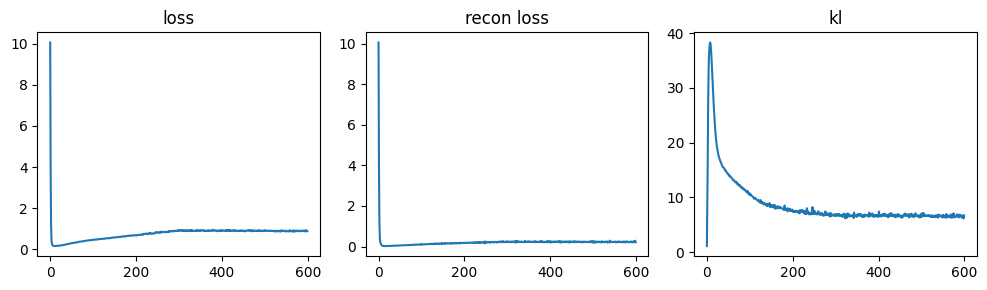

In [ ]:
model = DeepVAE(input_dim=2, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM)

history = train_vae(
    model,
    train_loader,
    epochs=EPOCHS,
    lr=LR,
    target_beta=BETA,
    anneal_epochs=ANNEAL_EPOCHS
)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.plot(history['loss'])
plt.title('loss')

plt.subplot(1, 3, 2)
plt.plot(history['recon'])
plt.title('recon loss')

plt.subplot(1, 3, 3)
plt.plot(history['kl'])
plt.title('kl')
plt.tight_layout()
plt.show()


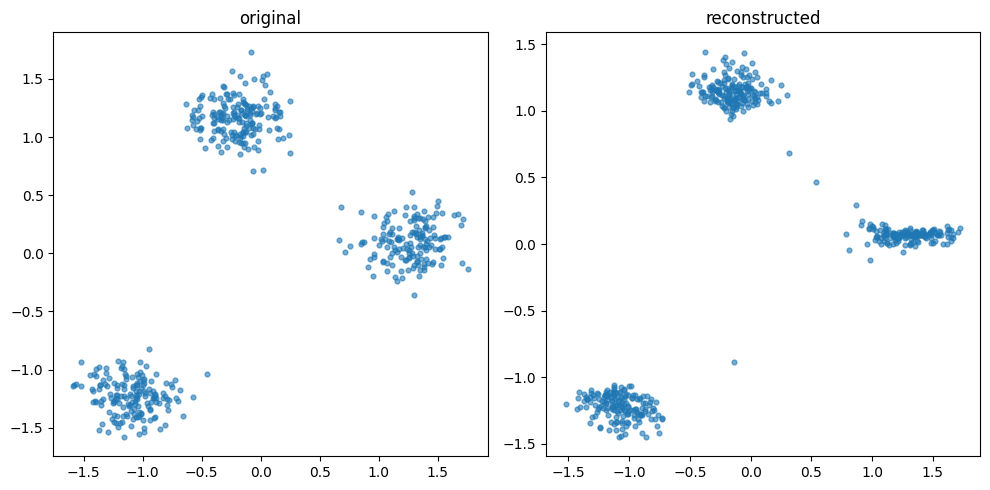

In [ ]:
def plot_reconstructions(model, data, n=500):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(data[:n])

    data_np = data[:n].numpy()
    recon_np = recon.numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(data_np[:, 0], data_np[:, 1], s=12, alpha=0.6)
    axes[0].set_title('original')

    axes[1].scatter(recon_np[:, 0], recon_np[:, 1], s=12, alpha=0.6)
    axes[1].set_title('reconstructed')

    plt.tight_layout()
    plt.show()

plot_reconstructions(model, all_data)


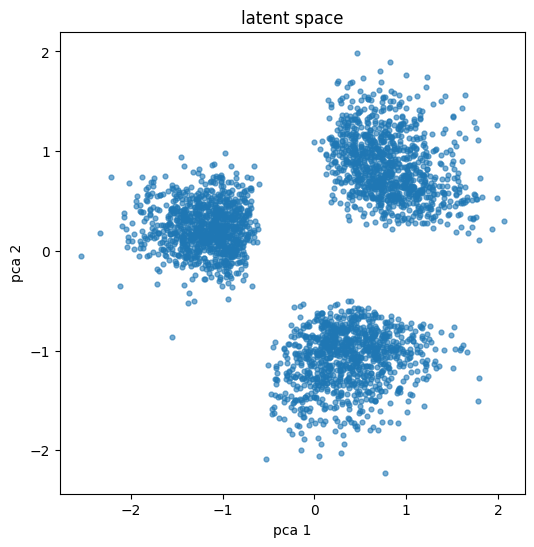

avg sigma: 0.700905442237854


In [ ]:
from sklearn.decomposition import PCA

def plot_latent_space(model, data):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(data)

    mu_np = mu.numpy()
    latent_dim = mu_np.shape[1]

    if latent_dim > 2:
        pca = PCA(n_components=2)
        mu_plot = pca.fit_transform(mu_np)
        xlabel, ylabel = 'pca 1', 'pca 2'
    else:
        mu_plot = mu_np
        xlabel, ylabel = 'z1', 'z2'

    plt.figure(figsize=(6, 6))
    plt.scatter(mu_plot[:, 0], mu_plot[:, 1], s=12, alpha=0.6)
    plt.title('latent space')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    std = torch.exp(0.5 * logvar)
    print('avg sigma:', std.mean().item())

plot_latent_space(model, all_data)


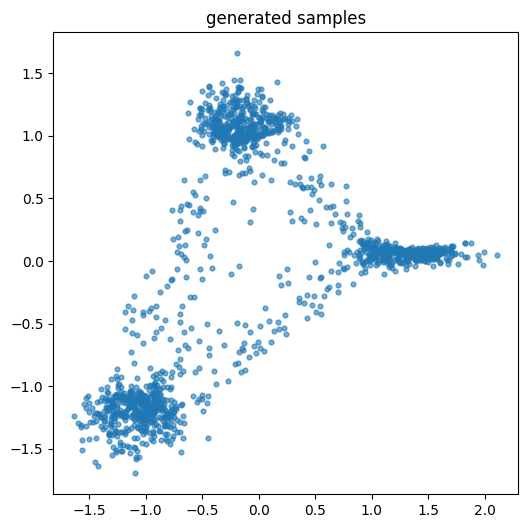

In [ ]:
def plot_generated_samples(model, n=1500):
    model.eval()
    latent_dim = model.encoder[-1].out_features // 2

    with torch.no_grad():
        z = torch.randn(n, latent_dim)
        samples = model.decode(z).numpy()

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.6)
    plt.title('generated samples')
    plt.show()

plot_generated_samples(model)
